# Figure 2: WGAN-GP Training Dynamics and Evaluation of Synthetic Promoters (SPs)

This notebook generates the panels for **Figure 2**, which illustrate the training stability of the WGAN-GP model and thoroughly evaluate the similarity between Synthetic Promoters (SPs) and Natural Promoters (NPs).

The analyses presented in this figure include:

*   **Training Stability**: Discriminator validation loss curves across various hyperparameter settings (z-dimension, generator/discriminator dimensions), demonstrating stable model convergence.
*   **K-mer Frequency Analysis**: 
    *   The progressive improvement of $R^2$ scores for 4, 5, and 6-mer frequencies during training, compared against natural test set benchmarks.
    *   A scatter plot comparing 6-mer frequencies between NPs and SPs, explicitly highlighting the conservation of TATA-box motifs and reporting the Pearson Correlation Coefficient (PCC).
*   **Functional Activity**: A comparison of the predicted activity distributions (log2 enrichment) for Natural Promoters vs. Synthetic Promoters.
*   **Sequence Properties & Diversity**:
    *   Evolution of **Jaccard Distance** and **Levenshtein Distance** across training iterations to assess sequence diversity.
    *   **GC Content** distribution of generated sequences compared to the natural baseline.
*   **DNA Shape Features**: Comparative density distributions of four key DNA structural features (**MGW**, **ProT**, **Roll**, **HelT**) for Native, GAN-generated, and Random sequences, verifying that SPs capture the structural properties of natural DNA.

## Training WGAN

### valid loss

['z_dim_30_gen_dim_50_disc_dim_50', 'z_dim_30_gen_dim_100_disc_dim_100', 'z_dim_30_gen_dim_150_disc_dim_150', 'z_dim_50_gen_dim_50_disc_dim_50', 'z_dim_50_gen_dim_100_disc_dim_100', 'z_dim_50_gen_dim_150_disc_dim_150', 'z_dim_70_gen_dim_50_disc_dim_50', 'z_dim_70_gen_dim_100_disc_dim_100', 'z_dim_70_gen_dim_150_disc_dim_150', 'z_dim_100_gen_dim_200_disc_dim_200']


Text(0, 0.5, 'Discriminator validation loss')

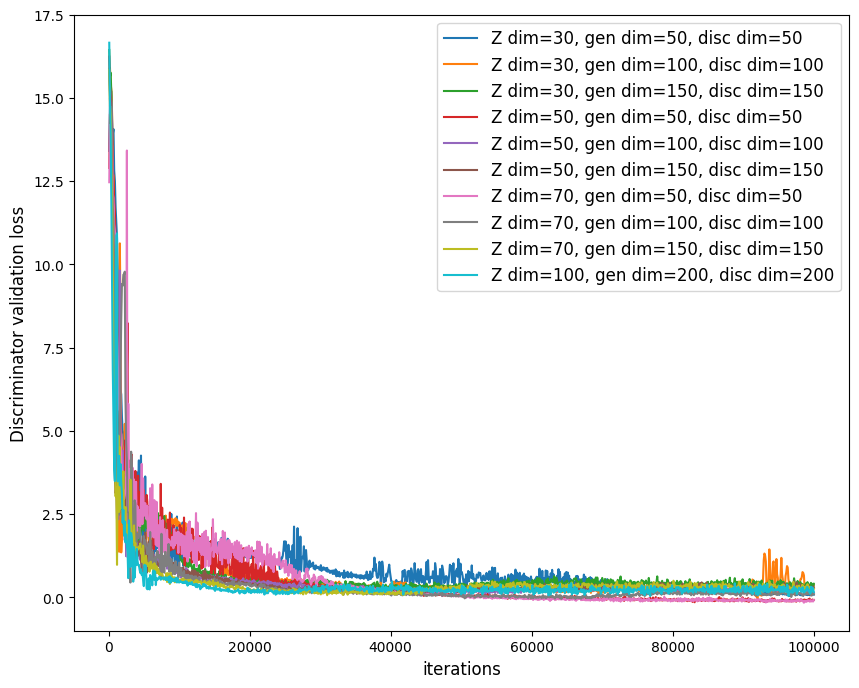

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
from functools import reduce
from sklearn.metrics import r2_score

import tensorflow as tf
os.environ["CUDA_VISIBLE_DEVICES"]='0'

all_dir_list = []
for a in [30,50,70]:
    for b in [50,100,150]:
        all_dir_list.append('z_dim_%s_gen_dim_%s_disc_dim_%s'%(a,b,b))
all_dir_list.append('z_dim_100_gen_dim_200_disc_dim_200')
print(all_dir_list)

plt.figure(figsize=(10, 8))
for i in all_dir_list:
    loss = pd.read_csv('../wgan-gp/%s/valid_disc_diff.csv'%i,header=None)
    label= ''.join(['Z dim=',i.split('_')[2],', gen dim=',i.split('_')[-1],', disc dim=',i.split('_')[-1]])
    sns.lineplot(x=loss[0], y=-loss[1],linewidth=1.5,label=label)

plt.yticks(size = 14)
plt.xticks(size = 14)
plt.legend(prop={'size': 12}, frameon=False)
plt.xlabel("Iterations", fontdict={'size': 16, 'weight':'bold'})
plt.ylabel("Discriminator Validation Loss", fontdict={'size': 16, 'weight':'bold'})
plt.title("Discriminator Training Stability", fontsize=20, fontweight='bold', pad=20)

sns.despine()
plt.tight_layout()
#plt.savefig('valid_loss.svg',dpi=1000)
plt.show()

### k-mer calculate

4-mer Test Set R2: 0.9784
5-mer Test Set R2: 0.9531
6-mer Test Set R2: 0.8928


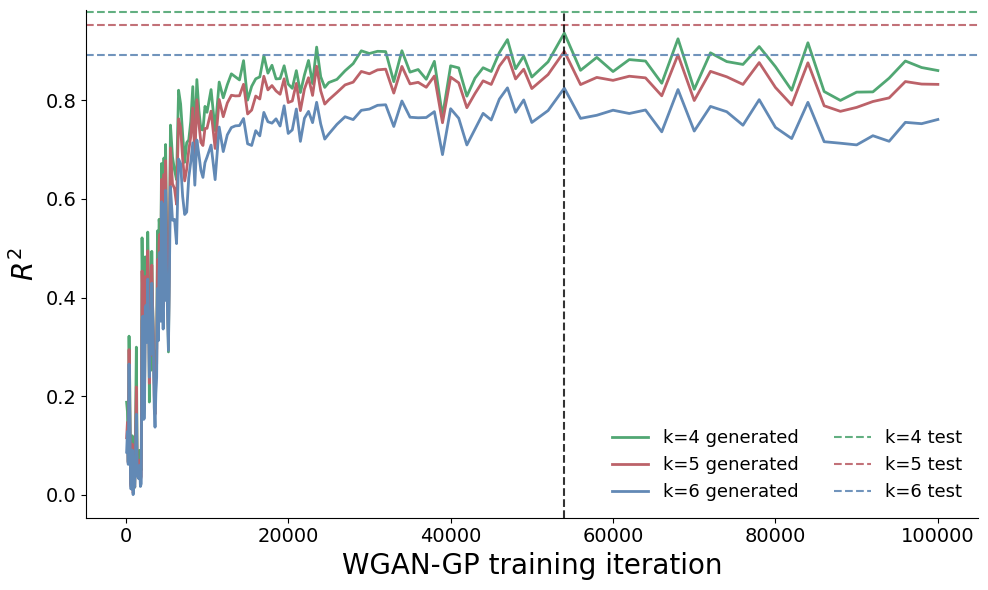

In [ ]:
from utils import accumulate_kmer_frequencies
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import random
import os

# Set random seed for reproducibility
seed = 2024
random.seed(seed)
np.random.seed(seed)

# Define sample size and k-mer values to check
num_samples = 640
k_mer_values = [4, 5, 6]

# Load dataset
data = pd.read_excel('../data/Natural promoters.xlsx')
data_train = data[data.dataset == 'training set']
data_test = data[data.dataset == 'test set']

# Prepare sequences
train_seq = list(data_train.sequence)
# Randomly sample sequences from the test set
test_seq = random.sample(list(data_test.sequence), num_samples)

r2_results = {}

# Calculate correlation of k-mer frequencies between training and test sets
# This serves as the benchmark/ceiling for the generated sequences
for k in k_mer_values:
    accumulated_vector_train = accumulate_kmer_frequencies(train_seq, k)
    accumulated_vector_test = accumulate_kmer_frequencies(test_seq, k)
    
    # Calculate R-squared value (using squared correlation coefficient)
    r2 = np.corrcoef(accumulated_vector_train, accumulated_vector_test)[0, 1]**2
    r2_results[k] = r2

# Print the results for each k-mer
for k, r2 in r2_results.items():
    print(f'{k}-mer Test Set R2: {r2:.4f}')

# Load and Plot Pre-calculated Data
file_path = './data_for_plot/train_gen.txt'
if os.path.exists(file_path):
    r2_df = pd.read_csv(file_path, sep='\t', index_col=0)
    
    # Initialize Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare X-axis data (iterations)
    x_values = [int(i) for i in r2_df.index]
    
    # Define colors for k=4, 5, 6 (Green, Red, Blue) matching the publication style
    colors = {4: '#51a773', 5: '#bc6269', 6: '#6289b5'}
    
    # 1. Plot Generated Sequences R2 (Solid Lines)
    for k in k_mer_values:
        col_name = str(k)
        if col_name in r2_df.columns:
            ax.plot(x_values, r2_df[col_name], label=f'k={k} generated', color=colors[k], linewidth=2)
            
    # 2. Plot Test Set R2 Benchmark (Dashed Lines)
    for k in k_mer_values:
         if k in r2_results:
            ax.axhline(y=r2_results[k], color=colors[k], linestyle='--', label=f'k={k} test', linewidth=1.5, alpha=0.9)

    # 3. Add Vertical Line at 54000 (Model Checkpoint)
    ax.axvline(x=54000, color='black', linestyle='--', linewidth=1.5, alpha=0.8)

    # Styling and Labels
    ax.set_xlabel('WGAN-GP Training Iteration', fontsize=16, fontweight='bold')
    ax.set_ylabel(r'$R^2$ Score', fontsize=16, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_title("K-mer Frequency $R^2$ Growth", fontsize=20, fontweight='bold', pad=20)
    
    # Configure Legend (Two Columns)
    ax.legend(ncol=2, prop={'size': 13}, loc='lower right', frameon=False)
    
    # Clean up layout
    sns.despine() 
    plt.tight_layout()
    plt.show()
else:
    print(f"Error: Pre-calculated data file not found at {file_path}. Please ensure the file exists.")

6-mer PCC: 0.9081


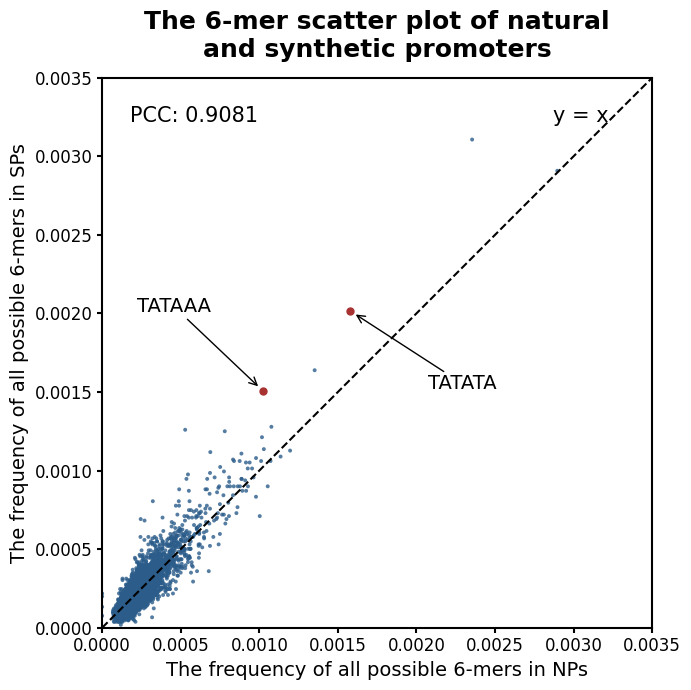

In [ ]:
from utils import accumulate_kmer_frequencies
from functools import reduce
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Load Reference Data
if 'data_train' not in locals():
    data = pd.read_excel('../data/Natural promoters.xlsx')
    data_train = data[data.dataset == 'training set']
train_seq = list(data_train.sequence)

# Load Generated Data
generated_seqs = []
sample_file = '../wgan-gp/z_dim_100_gen_dim_200_disc_dim_200/samples/samples_54000'
with open(sample_file, 'r') as f:
    for line in f:
        generated_seqs.append(line.strip())

# Calculate 6-mer Frequencies
k = 6
accumulated_vector_natural = accumulate_kmer_frequencies(train_seq, k)
accumulated_vector_generated = accumulate_kmer_frequencies(generated_seqs, k)

# Calculate Pearson Correlation
pcc, _ = pearsonr(accumulated_vector_natural, accumulated_vector_generated)

# Identify indices for TATA boxes
bases = ['A', 'T', 'C', 'G']
kmer_all = reduce(lambda x,y: [i+j for i in x for j in y], [bases] * k)
idx_tataaa = kmer_all.index('TATAAA')
idx_tatata = kmer_all.index('TATATA')

# Plotting
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect('equal')

# Scatter Plot
ax.scatter(accumulated_vector_natural, accumulated_vector_generated, 
           s=10, c='#2b5c8a', alpha=0.8, edgecolors='none', label='6-mers')

# Diagonal Line
limit = 0.0035
ax.plot([0, limit], [0, limit], 'k--', linewidth=1.5, label='y = x')

# Highlight TATA
highlight_color = '#a83232'
ax.scatter(accumulated_vector_natural[idx_tataaa], accumulated_vector_generated[idx_tataaa], 
           s=40, c=highlight_color, zorder=10)
ax.scatter(accumulated_vector_natural[idx_tatata], accumulated_vector_generated[idx_tatata], 
           s=40, c=highlight_color, zorder=10)

# Annotations
ax.text(0.05, 0.92, f'PCC: {pcc:.4f}', transform=ax.transAxes, fontsize=16, fontweight='bold')
ax.text(0.82, 0.92, 'y = x', transform=ax.transAxes, fontsize=16)

# Arrows
ax.annotate('TATAAA', 
            xy=(accumulated_vector_natural[idx_tataaa], accumulated_vector_generated[idx_tataaa]), 
            xytext=(accumulated_vector_natural[idx_tataaa] - 0.0008, accumulated_vector_generated[idx_tataaa] + 0.0005),
            fontsize=14, fontweight='bold',
            arrowprops=dict(facecolor='black', arrowstyle='->', shrinkA=0, shrinkB=5))

ax.annotate('TATATA', 
            xy=(accumulated_vector_natural[idx_tatata], accumulated_vector_generated[idx_tatata]), 
            xytext=(accumulated_vector_natural[idx_tatata] + 0.0005, accumulated_vector_generated[idx_tatata] - 0.0005),
            fontsize=14, fontweight='bold',
            arrowprops=dict(facecolor='black', arrowstyle='->', shrinkA=0, shrinkB=5))

# Labels and Title
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.set_xlabel('6-mer Frequency in NPs', fontsize=16)
ax.set_ylabel('6-mer Frequency in SPs', fontsize=16)
ax.set_title('6-mer Frequency Correlation', fontsize=20, fontweight='bold', pad=20)

sns.despine()
ax.tick_params(width=1.5, labelsize=14)

plt.tight_layout()
plt.show()

## Activity distributions of natural and synthetic promoters

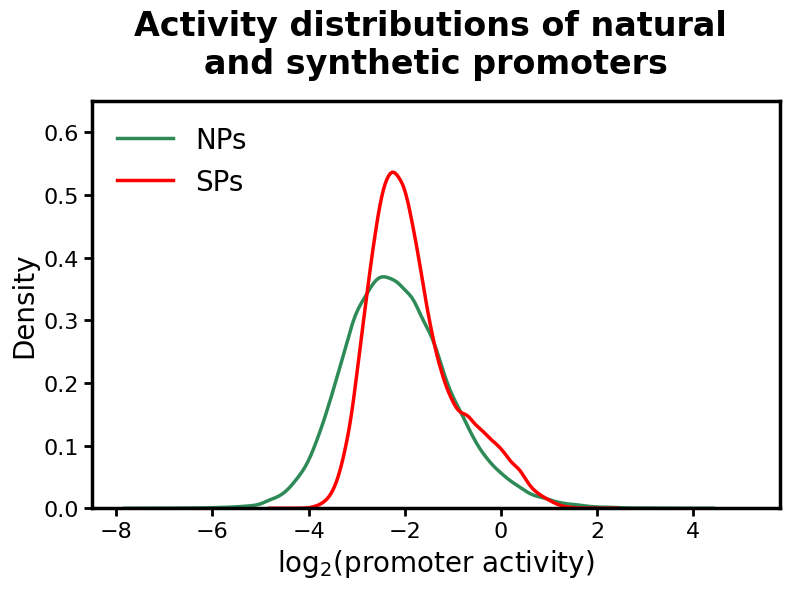

In [ ]:
import os
from utils import one_hot_encode, suppress_tf_warnings
suppress_tf_warnings()
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Load model
model_path = '../data/predictor.h5'
if not os.path.exists(model_path):
    model_path = '/home/xlxiang/TargetGAN-main/data/predictor.h5'
model = keras.models.load_model(model_path)

# Load Data
data_np = pd.read_excel('../data/Natural promoters.xlsx')
activities_np = data_np['enrichment'].values

sp_file_path = '../samples/WGAN-GP-54000-76851.txt'
data_sp = pd.read_csv(sp_file_path, header=None)
sp_sequences = data_sp[0].tolist()

sp_onehot = np.array([one_hot_encode(seq) for seq in sp_sequences])
predicted_activities_sp = model.predict(sp_onehot, verbose=0)
activities_sp = np.squeeze(predicted_activities_sp)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

sns.kdeplot(activities_np, color="seagreen", linewidth=3, label='Natural Promoters (NPs)', ax=ax)
sns.kdeplot(activities_sp, color="red", linewidth=3, label='Synthetic Promoters (SPs)', ax=ax)

# Styling
ax.set_title('Promoter Activity Distributions', fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel(r'log$_2$(Promoter Activity)', fontsize=18)
ax.set_ylabel('Density', fontsize=18)
ax.set_xlim(-8.5, 5.8)
ax.set_ylim(0, 0.65)
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=6)
legend = ax.legend(frameon=False, fontsize=16, loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

## Sequence properties: Jaccard distance, Levenshtein distance, and GC content

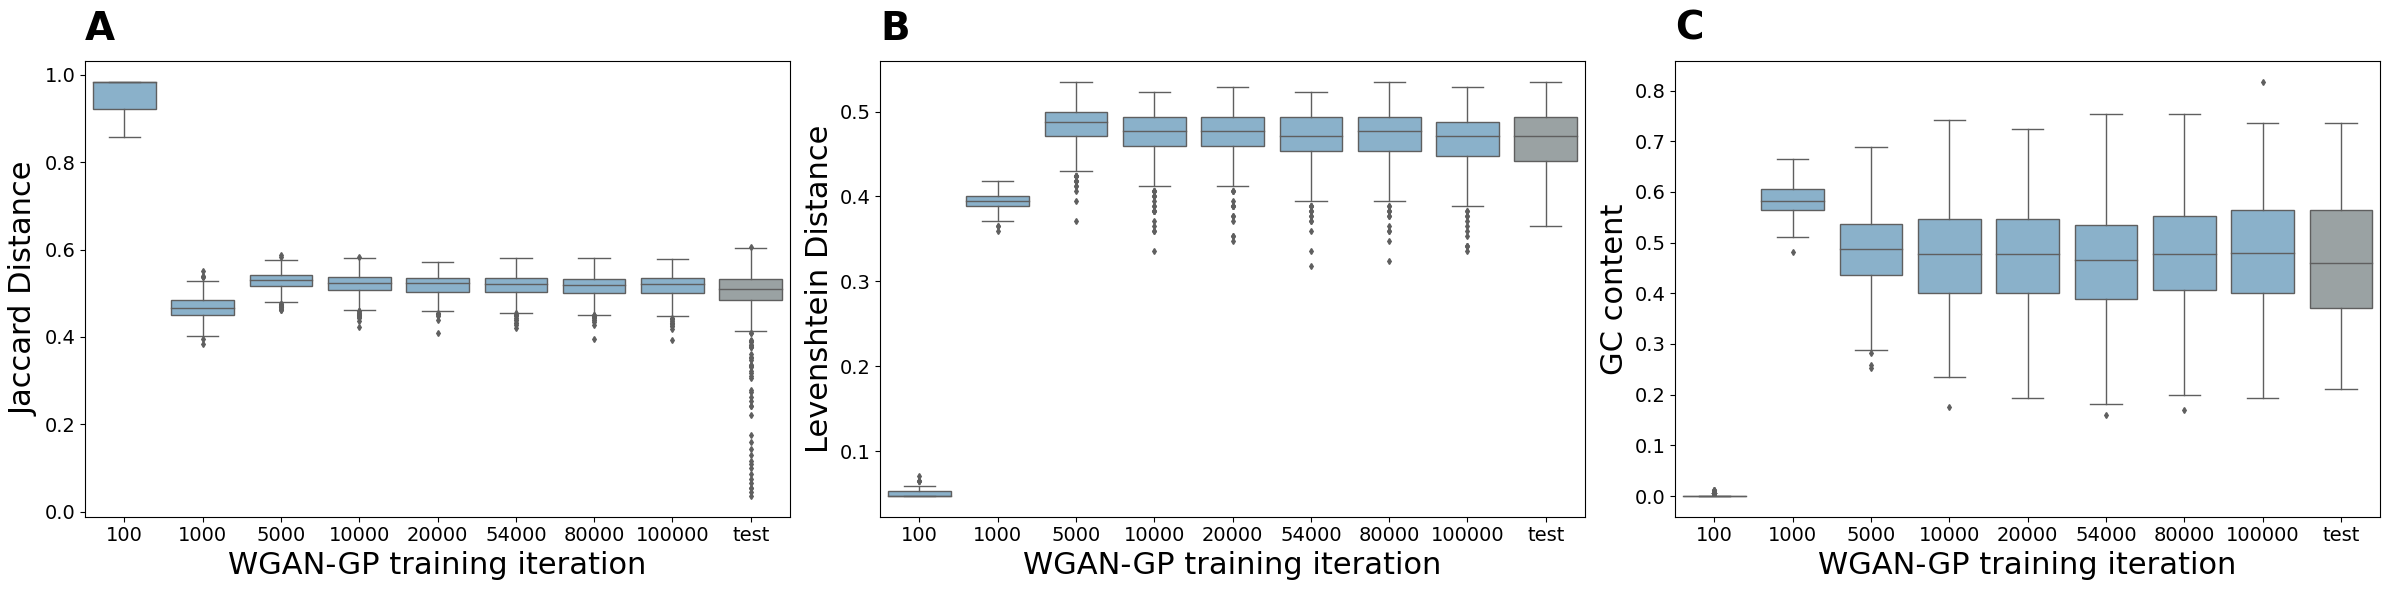

In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import utils
importlib.reload(utils)
from utils import gc_content

seed = 2024
random.seed(seed)
np.random.seed(seed)

iterations = ['100','1000','5000', '10000','20000','54000','80000','100000']
jaccard_file = './data_for_plot/jaccard_min.txt'
levenshtein_file = './data_for_plot/Levenshtein_min.txt'

if os.path.exists(jaccard_file):
    jaccard_df = pd.read_csv(jaccard_file, sep='\t')
else:
    jaccard_df = pd.DataFrame()

if os.path.exists(levenshtein_file):
    levenshtein_df = pd.read_csv(levenshtein_file, sep='\t')
else:
    levenshtein_df = pd.DataFrame()

# Calculate GC df (omitting detailed recalculation code for brevity if already run, but ensuring variables exist)
# ... [Same GC calculation logic as before] ...
gc_df = pd.DataFrame()
for it in iterations:
    gc_values = []
    sample_file = f'../wgan-gp/z_dim_100_gen_dim_200_disc_dim_200/samples/samples_{it}'
    if os.path.exists(sample_file):
        with open(sample_file, 'r') as f:
            for line in f:
                if line.strip(): gc_values.append(gc_content(line.strip()))
        gc_df[it] = gc_values

nat_promoters_file = '../data/Natural promoters.xlsx'
if os.path.exists(nat_promoters_file):
    data_nat = pd.read_excel(nat_promoters_file)
    data_test = data_nat[data_nat.dataset == 'test set']
    test_sample_seqs = random.sample(list(data_test.sequence), 640)
    gc_df['test'] = [gc_content(seq) for seq in test_sample_seqs]

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
palette_blue = ["#7FB3D5"] * len(iterations) + ["#99A3A4"]

# Subplot E: Jaccard
if not jaccard_df.empty:
    sns.boxplot(data=jaccard_df, palette=palette_blue, linewidth=1.5, fliersize=3, ax=axes[0])
    axes[0].set_ylabel('Jaccard Distance', fontsize=18)
    axes[0].set_xlabel('Training Iteration', fontsize=18)
    axes[0].tick_params(axis='both', labelsize=14)
    axes[0].set_title('Sequence Diversity (Jaccard)', fontsize=22, fontweight='bold', pad=20)

# Subplot F: Levenshtein
if not levenshtein_df.empty:
    sns.boxplot(data=levenshtein_df, palette=palette_blue, linewidth=1.5, fliersize=3, ax=axes[1])
    axes[1].set_ylabel('Levenshtein Distance', fontsize=18)
    axes[1].set_xlabel('Training Iteration', fontsize=18)
    axes[1].tick_params(axis='both', labelsize=14)
    axes[1].set_title('Sequence Diversity (Levenshtein)', fontsize=22, fontweight='bold', pad=20)

# Subplot G: GC Content
if not gc_df.empty:
    colors = ["#7FB3D5"] * (len(gc_df.columns) - 1) + ["#99A3A4"] 
    sns.boxplot(data=gc_df, palette=colors, linewidth=1.5, fliersize=3, ax=axes[2])
    axes[2].set_ylabel('GC Content', fontsize=18)
    axes[2].set_xlabel('Training Iteration', fontsize=18)
    axes[2].tick_params(axis='both', labelsize=14)
    axes[2].set_title('GC Content Distribution', fontsize=22, fontweight='bold', pad=20)

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

## DNA shape 

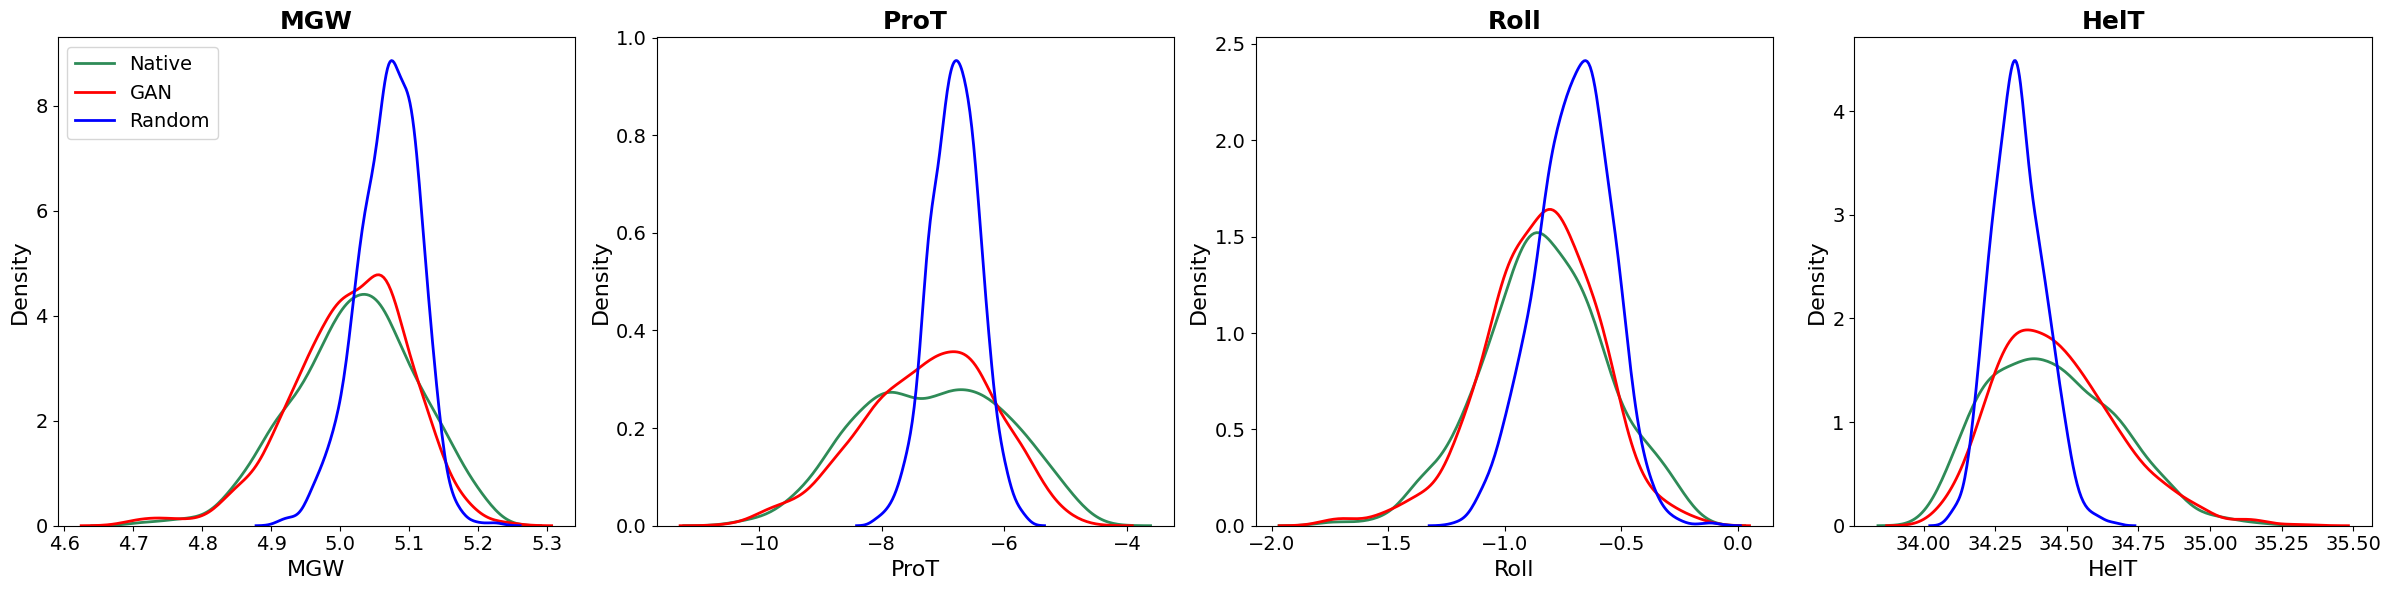

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import load_dna_shape_means

features = ['MGW', 'ProT', 'Roll', 'HelT']
base_path = '/home/xlxiang/TargetGAN-main/notebooks/data_for_plot/DNA shape'

datasets = {
    'Native': {'path_pattern': os.path.join(base_path, 'native_seq_640_dna_shape', '{}'), 'color': 'seagreen'},
    'GAN': {'path_pattern': os.path.join(base_path, 'gen_seq_640_dna_shape', 'phpImvP7c.{}'), 'color': 'red'},
    'Random': {'path_pattern': os.path.join(base_path, 'random_seq_640_dna_shape', '{}'), 'color': 'blue'}
}

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
plt.subplots_adjust(wspace=0.3)

for idx, feature in enumerate(features):
    ax = axes[idx]
    
    for label, config in datasets.items():
        file_path = config['path_pattern'].format(feature)
        data = load_dna_shape_means(file_path)
        if len(data) > 0:
            sns.kdeplot(data, color=config['color'], ax=ax, label=label, linewidth=2.5)
    
    ax.set_title(feature, fontsize=22, fontweight='bold', pad=15)
    ax.set_xlabel(feature, fontsize=18)
    ax.set_ylabel("Density", fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=16)
    
    if idx == 0:
        ax.legend(fontsize=14, frameon=False) # Remove legend frame
    
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()